# Использование метода тяжелого шарика и функции потерь smooth hinge loss для бинарной классификации датасета Iris

В датасете `Iris` целевая переменная разделена на 3 класса. Для бинарной классификации возьмем классы 0 и 1 и один из признаков.

In [2]:
import sys
from pathlib import Path

src_path = Path("../src").resolve()
sys.path.append(str(src_path))

from scipy.optimize import differential_evolution
from diff_evol import de_objective
from hb import heavy_ball
from mytypes import Array
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

## 1. Загрузка датасета

In [3]:
data = load_iris()
X = data.data[:100, 2:3]
y = data.target

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (100, 1)
Shape of y: (150,)


In [4]:
# Выбираем только два класса
# Например, исключаем 2 класс
mask = y != 2
y = y[mask]
y_bin = np.where(y == 0, -1, 1)
y_bin

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

## 2. Применение метода HB

In [5]:
# Определим функцию smooth hinge loss и ее градиент


# Smooth hinge loss для одного объекта
def smooth_hinge_one_sample(w: Array, x: Array, y: float) -> float:

    margin: float = float(y * np.dot(w, x))

    if margin <= 0.0:
        return 0.5 - margin
    elif margin < 1.0:
        return 0.5 * (1.0 - margin) ** 2
    else:
        return 0.0


# Smooth hinge loss по всем объектам выборки


def smooth_hinge(w: Array) -> float:
    return float(
        np.mean(
            [smooth_hinge_one_sample(w, xi, yi) for xi, yi in zip(X, y_bin)]
        )
    )


# Градиент по одному объекту


def grad_one_sample(w: Array, x: Array, y: float) -> Array:

    margin: float = float(y * np.dot(w, x))

    if margin <= 0.0:
        return -y * x
    elif margin < 1.0:
        return -(1.0 - margin) * y * x
    else:
        return np.zeros_like(w)


# Градиент по всем объектам


def grad_smooth_hinge(w: Array) -> Array:
    grad = np.zeros_like(w)
    for xi, yi in zip(X, y_bin):
        grad += grad_one_sample(w, xi, float(yi))
    return grad / len(X)

Найдем минимум smooth hinge loss.

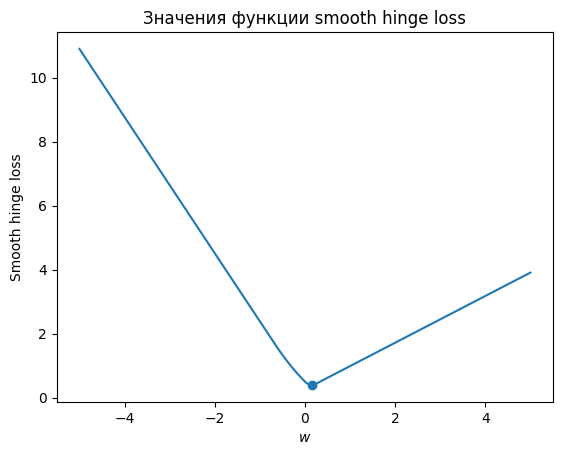

Минимум функции достигается в точке:  [0.15515516]
Минимум функции: [0.39345764]


In [6]:
w_grid = np.linspace(-5.0, 5.0, 1000)
loss_values = np.array([smooth_hinge(np.array([w])) for w in w_grid])
w_min = np.array([w_grid[np.argmin(loss_values)]])
loss_min = np.array([loss_values.min()])

plt.figure()
plt.plot(w_grid, loss_values)
plt.scatter([w_min], [loss_min])
plt.xlabel("$w$")
plt.ylabel("Smooth hinge loss")
plt.title("Значения функции smooth hinge loss")
plt.show()

print("Минимум функции достигается в точке: ", w_min)
print("Минимум функции:", loss_min)

### Поиск предельных циклов

In [7]:
# Ищем циклы около минимума функции
delta = 10.0
bounds = [(w_min[j] - delta, w_min[j] + delta) for j in range(len(w_min))]
bounds

[(np.float64(-9.844844844844845), np.float64(10.155155155155155))]

In [8]:
objective = de_objective(
    grad_f=grad_smooth_hinge, alpha=0.25, beta=0.1, num_iters=1000, cycle_len=2
)

In [9]:
result = differential_evolution(
    func=objective,
    bounds=bounds,
    strategy="best1bin",
    maxiter=100,
    popsize=15,
    tol=1e-5,
    polish=False,
    rng=42,
    disp=True,
)

differential_evolution step 1: f(x)= 0.07182703466508146


In [10]:
w0_star: Array = np.asarray(result.x, dtype=np.float64)
best_score: float = result.fun
print("Лучшая точка:", w0_star)
print("Лучшая оценка:", best_score)

traj = heavy_ball(
    grad_f=grad_smooth_hinge, x0=w0_star, T=1000, alpha=0.25, beta=0.1
)

Лучшая точка: [0.53657423]
Лучшая оценка: 0.07182703466508146


In [11]:
traj[-10:]

[array([0.08564772]),
 array([0.22487105]),
 array([0.08564772]),
 array([0.22487105]),
 array([0.08564772]),
 array([0.22487105]),
 array([0.08564772]),
 array([0.22487105]),
 array([0.08564772]),
 array([0.22487105])]

### Визуализация

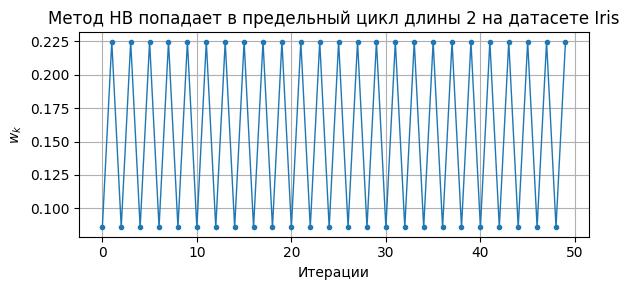

In [12]:
plt.figure(figsize=(6, 3))
plt.plot(traj[-50:], "o-", markersize=3, linewidth=1)
plt.xlabel("Итерации")
plt.ylabel("$w_k$")
plt.title("Метод HB попадает в предельный цикл длины 2 на датасете Iris")
plt.grid(True)
plt.tight_layout()
plt.show()

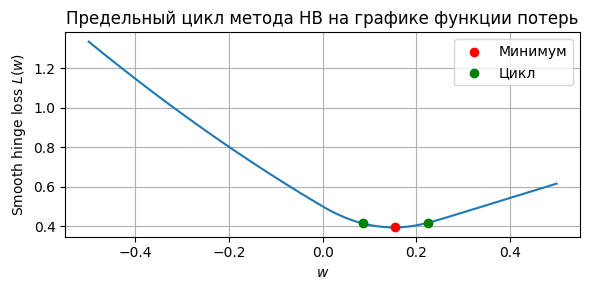

In [13]:
w_grid = np.linspace(-0.5, 0.5, 200)
loss_vals = [smooth_hinge(np.array([w])) for w in w_grid]

plt.figure(figsize=(6, 3))
plt.plot(w_grid, loss_vals)
plt.scatter(
    [w_min], [smooth_hinge(w_min)], color="red", label="Минимум", zorder=5
)
plt.scatter(
    traj[-2:],
    [smooth_hinge(w) for w in traj[-2:]],
    color="green",
    label="Цикл",
    zorder=5,
)
plt.xlabel("$w$")
plt.ylabel("Smooth hinge loss $L(w)$")
plt.title("Предельный цикл метода HB на графике функции потерь")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()